# Forecast Challenege

In [19]:
import os
import re
import warnings
import numpy as np
import pandas as pd

from scipy.stats import skew

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")

# ============================================================================
# PARAMETERS
# ============================================================================

PROJECT_DIR = "/Users/zl17868/NHS-EAD-forecast"
DATA_PATH = "data/turingAI_forecasting_challenge_dataset.csv"

TARGET_KEYWORD = "estimated_avoidable_deaths"

ASSESSMENT_CUTOFF = "2025-09-30 00:00:00"

TRAIN_WINDOW = 90
HORIZON = 10
ALPHA_VAL = 0.5

RANDOM_STATE = 123

os.chdir(PROJECT_DIR)

# Read Data

In [29]:
# ============================================================================
# 1. LOAD DATA FROM ZIP + DATE PROCESSING
# ============================================================================
from pathlib import Path
import zipfile

RAW_ZIP = Path("data/turingAI_forecasting_challenge_dataset.csv.zip")

ASSESSMENT_END = pd.Timestamp("2025-09-30 00:00:00")

with zipfile.ZipFile(RAW_ZIP) as z:
    print("Files in zip:", z.namelist())
    with z.open(z.namelist()[0]) as f:
        raw = pd.read_csv(f, low_memory=False)

print("Raw shape:", raw.shape)
print("Raw metric count before datetime parsing:", raw["metric_name"].nunique())

# 关键：必须用 format="mixed"
raw["dt"] = pd.to_datetime(raw["dt"], format="mixed", errors="coerce")

print("Rows with failed datetime parsing:", raw["dt"].isna().sum())

raw = raw.dropna(subset=["dt"]).copy()

raw["date"] = raw["dt"].dt.normalize()

is_morning = raw["dt"].dt.strftime("%H:%M:%S") <= "12:00:00"

raw["midday_day"] = raw["date"].where(
    is_morning,
    raw["date"] + pd.Timedelta(days=1)
)

raw = raw[raw["dt"] <= ASSESSMENT_END].copy()

print("Raw metric count after filtering:", raw["metric_name"].nunique())

Files in zip: ['turingAI_forecasting_challenge_dataset.csv']
Raw shape: (16728656, 6)
Raw metric count before datetime parsing: 221
Rows with failed datetime parsing: 0
Raw metric count after filtering: 221


In [33]:
raw["dt"] = pd.to_datetime(raw["dt"], format="mixed", errors="coerce")
raw = raw.dropna(subset=["dt"]).copy()

raw["date"] = raw["dt"].dt.normalize()
raw["time"] = raw["dt"].dt.strftime("%H:%M:%S")
raw.head()

,dt,metric_name,coverage,value,coverage_label,variable_type,date,midday_day,time
0,2023-03-16 13:00:00,Patients in A&E,Bristol Royal Infirmary,35.0,BRI,feature,2023-03-16,2023-03-17,13:00:00
1,2023-03-16 13:00:00,4hr Breach Performance,Bristol Royal Infirmary,83.0,BRI,feature,2023-03-16,2023-03-17,13:00:00
2,2023-03-16 13:00:00,Total Breaches Since Midnight,Bristol Royal Infirmary,10.0,BRI,feature,2023-03-16,2023-03-17,13:00:00
3,2023-03-16 13:00:00,No. of DTAs,Bristol Royal Infirmary,8.0,BRI,feature,2023-03-16,2023-03-17,13:00:00
4,2023-03-16 13:00:00,Average Time to Triage,Bristol Royal Infirmary,12.0,BRI,feature,2023-03-16,2023-03-17,13:00:00


In [35]:
# ============================================================================
# 2. CREATE MIDDAY DAY + DAILY WIDE DATA
# ============================================================================

# If time <= 12:00:00, keep same date; otherwise assign to next day
raw["midday_day"] = np.where(
    raw["time"] <= "12:00:00",
    pd.to_datetime(raw["date"]),
    pd.to_datetime(raw["date"]) + pd.Timedelta(days=1)
)

# Aggregate to daily temporal resolution
daily_long = (
    raw
    .drop(columns=["coverage", "coverage_label", "variable_type", "dt", "date", "time"], errors="ignore")
    .groupby(["midday_day", "metric_name"], as_index=False)["value"]
    .mean()
)

# Pivot from long to wide format
forecasting_df = (
    daily_long
    .pivot(index="midday_day", columns="metric_name", values="value")
    .reset_index()
)

forecasting_df = forecasting_df.sort_values("midday_day").reset_index(drop=True)

print(forecasting_df.shape)
forecasting_df.head(10)

(930, 222)


metric_name,midday_day,% of beds occupied by patients with NCtR,% of open beds that are escalation beds,% of patients spending >12 hours in ED,(SWASFT) Number of HCP Incidents,(SWASFT) Number of NHS 111 Incidents,(Severnside) CAS Referred to ED,(Severnside) Calls Answered,(Severnside) Calls Answered Within 60 Seconds,(Severnside) Calls Received,...,WGH NCtR Beddays,WGH NCtR Patients,WGH P0 Discharges,WGH P1 NCtR Beddays,WGH P1 NCtR Patients,WGH P2 NCtR Beddays,WGH P2 NCtR Patients,WGH P3 NCtR Beddays,WGH P3 NCtR Patients,estimated_avoidable_deaths
0,2023-03-16,NaN,NaN,NaN,30.0,143.0,NaN,657.0,308.0,754.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.343927
1,2023-03-17,NaN,NaN,NaN,54.0,129.0,NaN,688.0,274.0,816.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.481654
2,2023-03-18,NaN,NaN,NaN,19.0,205.0,NaN,1190.0,429.0,1418.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.566728
3,2023-03-19,NaN,NaN,NaN,23.0,152.0,NaN,965.0,317.0,1152.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.497218
4,2023-03-20,NaN,NaN,NaN,29.0,126.0,NaN,733.0,276.0,873.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.833433
5,2023-03-21,NaN,NaN,NaN,58.0,134.0,NaN,700.0,363.0,806.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.122461
6,2023-03-22,NaN,NaN,NaN,51.0,155.0,NaN,670.0,303.0,1025.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.103790
7,2023-03-23,NaN,NaN,NaN,51.0,108.0,NaN,668.0,411.0,750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.977486
8,2023-03-24,NaN,NaN,NaN,40.0,96.0,NaN,745.0,586.0,795.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.505630
9,2023-03-25,NaN,NaN,NaN,22.0,195.0,NaN,1265.0,1206.0,1291.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.542099


In [37]:
# ============================================================================
# 3. CLEAN COLUMN NAMES
# ============================================================================

def clean_name(x):
    x = str(x).lower()
    x = re.sub(r"[0-9]", "", x)
    x = re.sub(r"[()]", "", x)
    x = re.sub(r"[ -]+", "_", x)
    x = x.replace("%", "pct")
    x = re.sub(r"[^a-zA-Z0-9_]", "", x)
    x = re.sub(r"_+", "_", x)
    x = x.strip("_")
    return x


def make_unique(names):
    seen = {}
    out = []
    for name in names:
        if name not in seen:
            seen[name] = 0
            out.append(name)
        else:
            seen[name] += 1
            out.append(f"{name}.{seen[name]}")
    return out


# Identify target column before cleaning
target_candidates = [
    c for c in forecasting_df.columns
    if TARGET_KEYWORD.lower() in str(c).lower()
]

if len(target_candidates) == 0:
    target_candidates = [
        c for c in forecasting_df.columns
        if ("avoidable" in str(c).lower()) and ("death" in str(c).lower())
    ]

if len(target_candidates) == 0:
    raise ValueError("Cannot find target column. Check metric_name values.")

target_raw = target_candidates[0]
print("Target raw column:", target_raw)

# Clean all names
new_cols = []
mapping = []

for c in forecasting_df.columns:
    if c == "midday_day":
        new_name = "midday_day"
    elif c == target_raw:
        new_name = "estimated_avoidable_deaths"
    else:
        new_name = clean_name(c)
    
    new_cols.append(new_name)
    mapping.append({"original_name": c, "new_name": new_name})

new_cols = make_unique(new_cols)
forecasting_df.columns = new_cols

abbrev_df = pd.DataFrame(mapping)

# Keep only rows where target exists
forecasting_df = forecasting_df.dropna(subset=["estimated_avoidable_deaths"]).reset_index(drop=True)

forecasting_df.head()

Target raw column: estimated_avoidable_deaths


,midday_day,pct_of_beds_occupied_by_patients_with_nctr,pct_of_open_beds_that_are_escalation_beds,pct_of_patients_spending_hours_in_ed,swasft_number_of_hcp_incidents,swasft_number_of_nhs_incidents,severnside_cas_referred_to_ed,severnside_calls_answered,severnside_calls_answered_within_seconds,severnside_calls_received,...,wgh_nctr_beddays,wgh_nctr_patients,wgh_p_discharges,wgh_p_nctr_beddays,wgh_p_nctr_patients,wgh_p_nctr_beddays.1,wgh_p_nctr_patients.1,wgh_p_nctr_beddays.2,wgh_p_nctr_patients.2,estimated_avoidable_deaths
0,2023-03-16,NaN,NaN,NaN,30.0,143.0,NaN,657.0,308.0,754.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.343927
1,2023-03-17,NaN,NaN,NaN,54.0,129.0,NaN,688.0,274.0,816.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.481654
2,2023-03-18,NaN,NaN,NaN,19.0,205.0,NaN,1190.0,429.0,1418.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.566728
3,2023-03-19,NaN,NaN,NaN,23.0,152.0,NaN,965.0,317.0,1152.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.497218
4,2023-03-20,NaN,NaN,NaN,29.0,126.0,NaN,733.0,276.0,873.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.833433


In [38]:
# ============================================================================
# 4. CAUSAL FEATURE ENGINEERING
# ============================================================================

df = forecasting_df.copy()
df = df.sort_values("midday_day").reset_index(drop=True)

TARGET = "estimated_avoidable_deaths"

base_predictors = [
    c for c in df.columns
    if c not in ["midday_day", TARGET]
]

# Ensure predictors are numeric
for c in base_predictors:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

feature_df = pd.DataFrame()
feature_df["midday_day"] = df["midday_day"]
feature_df[TARGET] = df[TARGET]

# --------------------------------------------------------------------------
# 4.1 Current-day predictor values
# These are allowed only if they are known at forecast origin.
# If challenge rules say current-day X is not known, change this to shift(1).
# --------------------------------------------------------------------------

for c in base_predictors:
    feature_df[c] = df[c]

# --------------------------------------------------------------------------
# 4.2 Causal rolling features
# Rolling mean/sd use current and past values only.
# No future values are used.
# --------------------------------------------------------------------------

ROLL_WINDOWS = [7]

for c in base_predictors:
    for w in ROLL_WINDOWS:
        feature_df[f"{c}_roll_mean_{w}"] = (
            df[c]
            .rolling(window=w, min_periods=max(2, w // 2))
            .mean()
        )
        
        feature_df[f"{c}_roll_sd_{w}"] = (
            df[c]
            .rolling(window=w, min_periods=max(2, w // 2))
            .std()
        )

# --------------------------------------------------------------------------
# 4.3 Lagged outcome
# This fixes leakage.
# At row t, y_lag3 = y[t-3], which is known at time t.
# It is then used to predict y[t+h].
# --------------------------------------------------------------------------

feature_df[f"{TARGET}_lag3"] = df[TARGET].shift(3)

# Optional extra lags, often useful for forecasting
feature_df[f"{TARGET}_lag7"] = df[TARGET].shift(7)
feature_df[f"{TARGET}_roll_mean_7"] = df[TARGET].shift(1).rolling(7, min_periods=3).mean()
feature_df[f"{TARGET}_roll_sd_7"] = df[TARGET].shift(1).rolling(7, min_periods=3).std()

# Drop rows where target itself is missing
feature_df = feature_df.dropna(subset=[TARGET]).reset_index(drop=True)

print(feature_df.shape)
feature_df.head()

(930, 666)


,midday_day,estimated_avoidable_deaths,pct_of_beds_occupied_by_patients_with_nctr,pct_of_open_beds_that_are_escalation_beds,pct_of_patients_spending_hours_in_ed,swasft_number_of_hcp_incidents,swasft_number_of_nhs_incidents,severnside_cas_referred_to_ed,severnside_calls_answered,severnside_calls_answered_within_seconds,...,wgh_p_nctr_patients.1_roll_mean_7,wgh_p_nctr_patients.1_roll_sd_7,wgh_p_nctr_beddays.2_roll_mean_7,wgh_p_nctr_beddays.2_roll_sd_7,wgh_p_nctr_patients.2_roll_mean_7,wgh_p_nctr_patients.2_roll_sd_7,estimated_avoidable_deaths_lag3,estimated_avoidable_deaths_lag7,estimated_avoidable_deaths_roll_mean_7,estimated_avoidable_deaths_roll_sd_7
0,2023-03-16,0.343927,NaN,NaN,NaN,30.0,143.0,NaN,657.0,308.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-03-17,0.481654,NaN,NaN,NaN,54.0,129.0,NaN,688.0,274.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-03-18,0.566728,NaN,NaN,NaN,19.0,205.0,NaN,1190.0,429.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-03-19,0.497218,NaN,NaN,NaN,23.0,152.0,NaN,965.0,317.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.343927,NaN,0.464103,0.112433
4,2023-03-20,0.833433,NaN,NaN,NaN,29.0,126.0,NaN,733.0,276.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.481654,NaN,0.472382,0.093282


In [39]:
# ============================================================================
# 5. TRAIN-ONLY SKEWNESS TRANSFORMER
# ============================================================================

class SkewnessTransformer(BaseEstimator, TransformerMixin):
    """
    Apply skewness-based transformations using training data only.
    
    Rules:
    - abs(skew) <= threshold: no transformation
    - right skew and all positive: log1p
    - right skew with non-positive values: sqrt(x - train_min + 1)
    - left skew: squared
    """
    
    def __init__(self, threshold=1.0):
        self.threshold = threshold
        self.transformations_ = None
        self.mins_ = None
    
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        n_features = X.shape[1]
        
        self.transformations_ = []
        self.mins_ = []
        
        for j in range(n_features):
            x = X[:, j]
            x = x[np.isfinite(x)]
            
            if len(x) < 3:
                self.transformations_.append("none")
                self.mins_.append(0.0)
                continue
            
            sk = skew(x, nan_policy="omit")
            train_min = np.nanmin(x)
            
            transformation = "none"
            
            if abs(sk) > self.threshold:
                if sk > self.threshold and np.all(x > 0):
                    transformation = "log1p"
                elif sk > self.threshold:
                    transformation = "sqrt"
                elif sk < -self.threshold:
                    transformation = "squared"
            
            self.transformations_.append(transformation)
            self.mins_.append(train_min)
        
        return self
    
    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()
        
        for j, transformation in enumerate(self.transformations_):
            if transformation == "log1p":
                # avoid invalid values if test has unexpected <= -1 values
                X[:, j] = np.log1p(np.clip(X[:, j], a_min=-0.999999, a_max=None))
            
            elif transformation == "sqrt":
                train_min = self.mins_[j]
                X[:, j] = np.sqrt(np.maximum(X[:, j] - train_min + 1, 0))
            
            elif transformation == "squared":
                X[:, j] = X[:, j] ** 2
            
            else:
                pass
        
        return X

In [204]:
# ============================================================================
# MODEL REGISTRY
# ============================================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import ElasticNet, Ridge, Lasso
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import HuberRegressor, BayesianRidge
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import RobustScaler

RANDOM_STATE = 123


def build_elastic_net(train_size):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("variance_filter", VarianceThreshold(threshold=1e-8)),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
            alpha=0.01,
            l1_ratio=0.5,
            max_iter=10000,
            random_state=RANDOM_STATE
        ))
    ])


def build_ridge(train_size):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("variance_filter", VarianceThreshold(threshold=1e-8)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ])


def build_lasso(train_size):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("variance_filter", VarianceThreshold(threshold=1e-8)),
        ("scaler", StandardScaler()),
        ("model", Lasso(
            alpha=0.01,
            max_iter=10000,
            random_state=RANDOM_STATE
        ))
    ])


def build_hist_gbr(train_size):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(
            loss="squared_error",
            max_iter=100,
            learning_rate=0.05,
            max_leaf_nodes=15,
            min_samples_leaf=10,
            l2_regularization=0.1,
            random_state=RANDOM_STATE
        ))
    ])


def build_hist_gbr_abs(train_size):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(
            loss="absolute_error",
            max_iter=100,
            learning_rate=0.05,
            max_leaf_nodes=15,
            min_samples_leaf=10,
            l2_regularization=0.1,
            random_state=RANDOM_STATE
        ))
    ])


def build_random_forest(train_size):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=6,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])


def build_extra_trees(train_size):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=200,
            max_depth=6,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
def build_huber(train_size):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("variance_filter", VarianceThreshold(threshold=1e-8)),
        ("scaler", RobustScaler()),
        ("model", HuberRegressor(
            epsilon=1.35,
            alpha=0.001,
            max_iter=1000
        ))
    ])
    
def build_bayesian_ridge(train_size):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("variance_filter", VarianceThreshold(threshold=1e-8)),
        ("scaler", StandardScaler()),
        ("model", BayesianRidge())
    ])
def build_pls(train_size):
    n_components = min(10, max(2, train_size // 15))
    
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("variance_filter", VarianceThreshold(threshold=1e-8)),
        ("scaler", StandardScaler()),
        ("model", PLSRegression(n_components=n_components))
    ])
    
def build_gbr_huber(train_size):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            loss="huber",
            n_estimators=150,
            learning_rate=0.03,
            max_depth=3,
            min_samples_leaf=10,
            subsample=0.8,
            random_state=RANDOM_STATE
        ))
    ])
def build_knn(train_size):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("variance_filter", VarianceThreshold(threshold=1e-8)),
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(
            n_neighbors=10,
            weights="distance"
        ))
    ])

MODEL_REGISTRY = {
    "elastic_net": build_elastic_net,
    "ridge": build_ridge,
    "lasso": build_lasso,
    "bayesian_ridge": build_bayesian_ridge,
    "huber": build_huber,
    # "pls": build_pls,
    "hist_gbr": build_hist_gbr,
    "hist_gbr_abs": build_hist_gbr_abs,
    "gbr_huber": build_gbr_huber,
    "random_forest": build_random_forest,
    "extra_trees": build_extra_trees,
    "knn": build_knn,
}

In [205]:
# ============================================================================
# UNIFIED BACKTEST FUNCTION
# ============================================================================

def run_backtest(
    model_builder,
    feature_df,
    feature_cols,
    target_col,
    train_window=90,
    horizon=10,
    backtest_step=14,
    max_origins=80,
    fast_horizons=(1, 5, 10),
    start_date=None,
    end_date=None,
    verbose=False
    ):
    """
    Generic rolling backtest for any sklearn-style model.
    
    model_builder: function returning a sklearn model/pipeline
    fast_horizons: tuple/list of horizons to evaluate, e.g. (1,5,10)
    """
    
    n = len(feature_df)
    
    all_origin_positions = np.arange(train_window - 1, n - horizon)

    origin_dates_all = pd.to_datetime(feature_df.loc[all_origin_positions, "midday_day"])

    if start_date is not None:
        start_date = pd.to_datetime(start_date)
        all_origin_positions = all_origin_positions[origin_dates_all >= start_date]
        origin_dates_all = pd.to_datetime(feature_df.loc[all_origin_positions, "midday_day"])

    if end_date is not None:
        end_date = pd.to_datetime(end_date)
        all_origin_positions = all_origin_positions[origin_dates_all <= end_date]
        origin_dates_all = pd.to_datetime(feature_df.loc[all_origin_positions, "midday_day"])

    origin_positions = all_origin_positions[::backtest_step]

    if max_origins is not None:
        origin_positions = origin_positions[-max_origins:]
        
    n_eval = len(origin_positions)
    
    pred_matrix = np.full((n_eval, horizon), np.nan)
    actual_matrix = np.full((n_eval, horizon), np.nan)
    
    forecast_info = []
    
    for row_id, origin_pos in enumerate(origin_positions):
        
        origin_date = feature_df.loc[origin_pos, "midday_day"]
        
        if verbose:
            print(f"Forecast {row_id + 1}/{n_eval} | origin = {origin_date}")
        
        X_origin = feature_df.loc[[origin_pos], feature_cols]
        
        for h in fast_horizons:
            
            max_train_origin = origin_pos - h
            
            if max_train_origin < 0:
                continue
            
            train_origin_positions = np.arange(0, max_train_origin + 1)
            
            if len(train_origin_positions) > train_window:
                train_origin_positions = train_origin_positions[-train_window:]
            
            if len(train_origin_positions) < 30:
                continue
            
            target_positions = train_origin_positions + h
            
            X_train = feature_df.loc[train_origin_positions, feature_cols]
            y_train = feature_df.loc[target_positions, target_col].values
            
            valid = np.isfinite(y_train)
            X_train = X_train.loc[valid]
            y_train = y_train[valid]
            
            if len(y_train) < 30:
                continue
            
            model = model_builder(train_size=len(y_train))
            model.fit(X_train, y_train)
            
            pred = model.predict(X_origin)[0]
            
            # target should not be negative
            pred = max(pred, 0)
            
            pred_matrix[row_id, h - 1] = pred
            actual_matrix[row_id, h - 1] = feature_df.loc[origin_pos + h, target_col]
        
        forecast_info.append({
            "forecast_id": row_id + 1,
            "origin_pos": origin_pos,
            "origin_date": origin_date
        })
    
    forecast_info_df = pd.DataFrame(forecast_info)
    
    return pred_matrix, actual_matrix, forecast_info_df

In [156]:
# ============================================================================
# METRICS FUNCTION
# ============================================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr

def compute_metrics(actual_matrix, pred_matrix):
    actual_flat = actual_matrix.flatten()
    pred_flat = pred_matrix.flatten()
    
    valid = np.isfinite(actual_flat) & np.isfinite(pred_flat)
    
    a = actual_flat[valid]
    p = pred_flat[valid]
    
    if len(a) < 3:
        return {
            "MSE": np.nan,
            "RMSE": np.nan,
            "MAE": np.nan,
            "R2": np.nan,
            "Pearson": np.nan,
            "Spearman": np.nan,
            "N": len(a)
        }
    
    return {
        "MSE": mean_squared_error(a, p),
        "RMSE": np.sqrt(mean_squared_error(a, p)),
        "MAE": mean_absolute_error(a, p),
        "R2": r2_score(a, p),
        "Pearson": pearsonr(a, p)[0],
        "Spearman": spearmanr(a, p)[0],
        "N": len(a)
    }
    
WINTER_CONFIGS = {
    "winter_2023_2024": {
        "start_date": "2023-11-01",
        "end_date": "2024-03-31"
    },
    "winter_2024_2025": {
        "start_date": "2024-11-01",
        "end_date": "2025-03-31"
    },
    "all_winter": {
        "start_date": None,
        "end_date": None
    }
}

In [165]:
def run_model_screening_for_period(
    period_name,
    start_date=None,
    end_date=None,
    backtest_step=7,
    fast_horizons=(1, 5, 10)
):
    rows = []
    results = {}
    
    for model_name, model_builder in MODEL_REGISTRY.items():
        print(f"Running {model_name} | {period_name}")
        
        pred_m, actual_m, info_m = run_backtest(
            model_builder=model_builder,
            feature_df=feature_df,
            feature_cols=feature_cols,
            target_col=TARGET,
            train_window=TRAIN_WINDOW,
            horizon=HORIZON,
            backtest_step=backtest_step,
            max_origins=None,
            fast_horizons=fast_horizons,
            start_date=start_date,
            end_date=end_date,
            verbose=False
        )
        
        metrics_m = compute_metrics(actual_m, pred_m)
        metrics_m["model"] = model_name
        metrics_m["period"] = period_name
        
        rows.append(metrics_m)
        
        results[model_name] = {
            "pred_matrix": pred_m,
            "actual_matrix": actual_m,
            "forecast_info": info_m,
            "metrics": metrics_m
        }
    
    summary = pd.DataFrame(rows)
    summary = summary[
        ["period", "model", "MSE", "RMSE", "MAE", "R2", "Pearson", "Spearman", "N"]
    ].sort_values("MSE")
    
    return summary, results


In [199]:
!pip install holidays


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [200]:
# ============================================================================
# CALENDAR + UK HOLIDAY FEATURES
# ============================================================================

import numpy as np
import pandas as pd

date_col = pd.to_datetime(feature_df["midday_day"])

# --------------------------------------------------------------------------
# Basic calendar features
# --------------------------------------------------------------------------

feature_df["day_of_week"] = date_col.dt.dayofweek   # Monday=0, Sunday=6
feature_df["month"] = date_col.dt.month
feature_df["day_of_month"] = date_col.dt.day
feature_df["day_of_year"] = date_col.dt.dayofyear
feature_df["week_of_year"] = date_col.dt.isocalendar().week.astype(int)
feature_df["quarter"] = date_col.dt.quarter

# Weekend
feature_df["is_weekend"] = feature_df["day_of_week"].isin([5, 6]).astype(int)

# Month start/end
feature_df["is_month_start"] = date_col.dt.is_month_start.astype(int)
feature_df["is_month_end"] = date_col.dt.is_month_end.astype(int)

# Quarter start/end
feature_df["is_quarter_start"] = date_col.dt.is_quarter_start.astype(int)
feature_df["is_quarter_end"] = date_col.dt.is_quarter_end.astype(int)

# Winter season: Nov-Mar
feature_df["is_winter"] = feature_df["month"].isin([11, 12, 1, 2, 3]).astype(int)

# Christmas / New Year operational pressure period
feature_df["is_christmas_period"] = (
    ((feature_df["month"] == 12) & (feature_df["day_of_month"] >= 20)) |
    ((feature_df["month"] == 1) & (feature_df["day_of_month"] <= 7))
).astype(int)

# --------------------------------------------------------------------------
# Cyclical encodings
# --------------------------------------------------------------------------

feature_df["dow_sin"] = np.sin(2 * np.pi * feature_df["day_of_week"] / 7)
feature_df["dow_cos"] = np.cos(2 * np.pi * feature_df["day_of_week"] / 7)

feature_df["month_sin"] = np.sin(2 * np.pi * feature_df["month"] / 12)
feature_df["month_cos"] = np.cos(2 * np.pi * feature_df["month"] / 12)

feature_df["doy_sin"] = np.sin(2 * np.pi * feature_df["day_of_year"] / 365.25)
feature_df["doy_cos"] = np.cos(2 * np.pi * feature_df["day_of_year"] / 365.25)

feature_df["week_sin"] = np.sin(2 * np.pi * feature_df["week_of_year"] / 52)
feature_df["week_cos"] = np.cos(2 * np.pi * feature_df["week_of_year"] / 52)

# --------------------------------------------------------------------------
# Interaction features
# --------------------------------------------------------------------------

feature_df["weekend_in_winter"] = (
    feature_df["is_weekend"] * feature_df["is_winter"]
)

feature_df["christmas_weekend"] = (
    feature_df["is_christmas_period"] * feature_df["is_weekend"]
)

# ============================================================================
# UK / ENGLAND BANK HOLIDAY FEATURES
# ============================================================================

try:
    import holidays
    
    # NHS Bristol: use England bank holidays
    uk_holidays = holidays.UnitedKingdom(subdiv="England")
    
    date_only = date_col.dt.date
    
    feature_df["is_bank_holiday"] = date_only.apply(
        lambda x: int(x in uk_holidays)
    )
    
    feature_df["is_day_before_bank_holiday"] = (date_col + pd.Timedelta(days=1)).dt.date.apply(
        lambda x: int(x in uk_holidays)
    )
    
    feature_df["is_day_after_bank_holiday"] = (date_col - pd.Timedelta(days=1)).dt.date.apply(
        lambda x: int(x in uk_holidays)
    )
    
    # Wider holiday window: +/- 3 days around bank holiday
    feature_df["near_bank_holiday_3d"] = 0
    
    for offset in range(-3, 4):
        shifted_dates = (date_col + pd.Timedelta(days=offset)).dt.date
        feature_df["near_bank_holiday_3d"] = np.maximum(
            feature_df["near_bank_holiday_3d"],
            shifted_dates.apply(lambda x: int(x in uk_holidays))
        )
    
    # Days since last bank holiday and days until next bank holiday
    all_dates = pd.Series(date_col.dt.date)
    
    holiday_dates = sorted([
        pd.to_datetime(d).date()
        for d in uk_holidays
    ])
    
    def days_since_last_holiday(x):
        past = [d for d in holiday_dates if d <= x]
        if len(past) == 0:
            return np.nan
        return (pd.to_datetime(x) - pd.to_datetime(past[-1])).days
    
    def days_until_next_holiday(x):
        future = [d for d in holiday_dates if d >= x]
        if len(future) == 0:
            return np.nan
        return (pd.to_datetime(future[0]) - pd.to_datetime(x)).days
    
    feature_df["days_since_bank_holiday"] = all_dates.apply(days_since_last_holiday)
    feature_df["days_until_bank_holiday"] = all_dates.apply(days_until_next_holiday)
    
except ImportError:
    print("Package 'holidays' is not installed. Run: pip install holidays")

In [201]:
# ============================================================================
# FEATURE GROUPS
# ============================================================================

calendar_features = [
    "day_of_week",
    "month",
    "day_of_month",
    "day_of_year",
    "week_of_year",
    "quarter",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_quarter_start",
    "is_quarter_end",
    "is_winter",
    "is_christmas_period",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "doy_sin",
    "doy_cos",
    "week_sin",
    "week_cos",
    "weekend_in_winter",
    "christmas_weekend"
]

holiday_features = [
    "is_bank_holiday",
    "is_day_before_bank_holiday",
    "is_day_after_bank_holiday",
    "near_bank_holiday_3d",
    "days_since_bank_holiday",
    "days_until_bank_holiday"
]

calendar_features = [c for c in calendar_features if c in feature_df.columns]
holiday_features = [c for c in holiday_features if c in feature_df.columns]

target_history_features = [
    c for c in feature_df.columns
    if c.startswith(TARGET + "_")
]

external_features = [
    c for c in feature_cols
    if c not in calendar_features
    and c not in holiday_features
    and c not in target_history_features
]

print("Target history features:", len(target_history_features))
print("Calendar features:", len(calendar_features))
print("Holiday features:", len(holiday_features))
print("External features:", len(external_features))

Target history features: 4
Calendar features: 23
Holiday features: 6
External features: 660


In [202]:
# ============================================================================
# FEATURE SETS WITH CALENDAR + HOLIDAY
# ============================================================================

FEATURE_SETS = {
    "target_history_only": target_history_features,
    
    "target_history_calendar": (
        target_history_features + calendar_features
    ),
    
    "target_history_calendar_holiday": (
        target_history_features + calendar_features + holiday_features
    ),
    
    "all_features_calendar_holiday": (
        target_history_features + calendar_features + holiday_features + external_features
    )
}

In [206]:
# ============================================================================
# RUN ALL MODELS: FAST SCREENING
# ============================================================================
feature_cols = [
    c for c in feature_df.columns
    if c not in ["midday_day", TARGET]
]

FAST_CONFIG = {
    "train_window": TRAIN_WINDOW,
    "horizon": HORIZON,
    "backtest_step": 14,
    "max_origins": 80,
    "fast_horizons": (1, 5, 10)
}

all_results = {}
summary_rows = []

for feature_set_name, fs_cols in FEATURE_SETS.items():
    
    print("\n########################################")
    print(f"Feature set: {feature_set_name}")
    print(f"Number of features: {len(fs_cols)}")
    print("########################################")
    
    for model_name, model_builder in MODEL_REGISTRY.items():
        
        print(f"\n==============================")
        print(f"Running model: {model_name}")
        print(f"Feature set: {feature_set_name}")
        print(f"n_features: {len(fs_cols)}")
        print(f"==============================")
        
        pred_matrix_m, actual_matrix_m, forecast_info_m = run_backtest(
            model_builder=model_builder,
            feature_df=feature_df,
            feature_cols=fs_cols,
            target_col=TARGET,
            train_window=FAST_CONFIG["train_window"],
            horizon=FAST_CONFIG["horizon"],
            backtest_step=FAST_CONFIG["backtest_step"],
            max_origins=FAST_CONFIG["max_origins"],
            fast_horizons=FAST_CONFIG["fast_horizons"],
            verbose=False
        )
        
        metrics_m = compute_metrics(actual_matrix_m, pred_matrix_m)
        metrics_m["model"] = model_name
        metrics_m["feature_set"] = feature_set_name
        metrics_m["n_features"] = len(fs_cols)
        
        summary_rows.append(metrics_m)
        
        result_key = f"{model_name}__{feature_set_name}"
        
        all_results[result_key] = {
            "model": model_name,
            "feature_set": feature_set_name,
            "n_features": len(fs_cols),
            "pred_matrix": pred_matrix_m,
            "actual_matrix": actual_matrix_m,
            "forecast_info": forecast_info_m,
            "metrics": metrics_m
        }


summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df[
    [
        "model",
        "feature_set",
        "n_features",
        "MSE",
        "RMSE",
        "MAE",
        "R2",
        "Pearson",
        "Spearman",
        "N"
    ]
].sort_values("MSE")

summary_df


########################################
Feature set: target_history_only
Number of features: 4
########################################

Running model: elastic_net
Feature set: target_history_only
n_features: 4

Running model: ridge
Feature set: target_history_only
n_features: 4

Running model: lasso
Feature set: target_history_only
n_features: 4

Running model: bayesian_ridge
Feature set: target_history_only
n_features: 4

Running model: huber
Feature set: target_history_only
n_features: 4

Running model: hist_gbr
Feature set: target_history_only
n_features: 4

Running model: hist_gbr_abs
Feature set: target_history_only
n_features: 4

Running model: gbr_huber
Feature set: target_history_only
n_features: 4

Running model: random_forest
Feature set: target_history_only
n_features: 4

Running model: extra_trees
Feature set: target_history_only
n_features: 4

Running model: knn
Feature set: target_history_only
n_features: 4

########################################
Feature set: target_

,model,feature_set,n_features,MSE,RMSE,MAE,R2,Pearson,Spearman,N
31,extra_trees,target_history_calendar_holiday,33,0.059806,0.244554,0.185678,0.437943,0.678973,0.651771,180
32,knn,target_history_calendar_holiday,33,0.060558,0.246085,0.191185,0.430881,0.682527,0.637623,180
30,random_forest,target_history_calendar_holiday,33,0.060640,0.246253,0.187670,0.430105,0.676933,0.649197,180
21,knn,target_history_calendar,27,0.061146,0.247277,0.192233,0.425355,0.678865,0.634211,180
20,extra_trees,target_history_calendar,27,0.061167,0.247320,0.188829,0.425154,0.672336,0.640040,180
28,hist_gbr_abs,target_history_calendar_holiday,33,0.062134,0.249268,0.188514,0.416065,0.653468,0.615377,180
42,extra_trees,all_features_calendar_holiday,693,0.062423,0.249847,0.194883,0.413348,0.673856,0.646997,180
19,random_forest,target_history_calendar,27,0.062452,0.249903,0.192612,0.413083,0.667199,0.628021,180
17,hist_gbr_abs,target_history_calendar,27,0.064179,0.253335,0.192390,0.396853,0.644768,0.599023,180
41,random_forest,all_features_calendar_holiday,693,0.064464,0.253897,0.199468,0.394172,0.665922,0.633857,180


In [207]:
def run_baseline_backtest(
    baseline_name,
    feature_df,
    target_col,
    train_window=90,
    horizon=10,
    backtest_step=7,
    fast_horizons=(1, 5, 10),
    start_date=None,
    end_date=None
):
    n = len(feature_df)
    
    all_origin_positions = np.arange(train_window - 1, n - horizon)
    origin_dates_all = pd.to_datetime(feature_df.loc[all_origin_positions, "midday_day"])
    
    if start_date is not None:
        all_origin_positions = all_origin_positions[origin_dates_all >= pd.to_datetime(start_date)]
        origin_dates_all = pd.to_datetime(feature_df.loc[all_origin_positions, "midday_day"])
    
    if end_date is not None:
        all_origin_positions = all_origin_positions[origin_dates_all <= pd.to_datetime(end_date)]
        origin_dates_all = pd.to_datetime(feature_df.loc[all_origin_positions, "midday_day"])
    
    origin_positions = all_origin_positions[::backtest_step]
    
    pred_matrix = np.full((len(origin_positions), horizon), np.nan)
    actual_matrix = np.full((len(origin_positions), horizon), np.nan)
    
    y = feature_df[target_col].values
    
    for row_id, origin_pos in enumerate(origin_positions):
        for h in fast_horizons:
            
            if baseline_name == "naive_last_value":
                pred = y[origin_pos]
            
            elif baseline_name == "naive_last_week":
                pred = y[origin_pos - 7] if origin_pos - 7 >= 0 else np.nan
            
            elif baseline_name == "rolling_mean_7":
                pred = np.nanmean(y[max(0, origin_pos - 6):origin_pos + 1])
            
            elif baseline_name == "rolling_mean_28":
                pred = np.nanmean(y[max(0, origin_pos - 27):origin_pos + 1])
            
            elif baseline_name == "ema_7":
                hist = pd.Series(y[:origin_pos + 1])
                pred = hist.ewm(span=7, adjust=False).mean().iloc[-1]
            
            elif baseline_name == "ema_14":
                hist = pd.Series(y[:origin_pos + 1])
                pred = hist.ewm(span=14, adjust=False).mean().iloc[-1]
            
            else:
                raise ValueError(f"Unknown baseline: {baseline_name}")
            
            pred_matrix[row_id, h - 1] = max(pred, 0) if np.isfinite(pred) else np.nan
            actual_matrix[row_id, h - 1] = y[origin_pos + h]
    
    return pred_matrix, actual_matrix

In [208]:
BASELINE_MODELS = [
    "naive_last_value",
    "naive_last_week",
    "rolling_mean_7",
    "rolling_mean_28",
    "ema_7",
    "ema_14"
]

baseline_rows = []
baseline_results = {}
for baseline_name in BASELINE_MODELS:
    pred_b, actual_b = run_baseline_backtest(
        baseline_name=baseline_name,
        feature_df=feature_df,
        target_col=TARGET,
        train_window=FAST_CONFIG["train_window"],
        horizon=FAST_CONFIG["horizon"],
        backtest_step=FAST_CONFIG["backtest_step"],
        fast_horizons=FAST_CONFIG["fast_horizons"],
    )
    
    m = compute_metrics(actual_b, pred_b)
    m["model"] = baseline_name
    baseline_rows.append(m)
    baseline_results[baseline_name] = {
        "pred_matrix": pred_b,
        "actual_matrix": actual_b,
        "metrics": m
    }
  
baseline_summary = pd.DataFrame(baseline_rows)
baseline_summary = baseline_summary[
    [ "model", "MSE", "RMSE", "MAE", "R2", "Pearson", "Spearman", "N"]
].sort_values("MSE")

baseline_summary

,model,MSE,RMSE,MAE,R2,Pearson,Spearman,N
3,rolling_mean_28,0.062072,0.249142,0.193947,0.416651,0.662906,0.620429,180
5,ema_14,0.065942,0.256791,0.199025,0.380284,0.669882,0.629350,180
2,rolling_mean_7,0.073005,0.270194,0.207545,0.313906,0.642631,0.582084,180
4,ema_7,0.083430,0.288843,0.219112,0.215927,0.628749,0.598827,180
1,naive_last_week,0.180583,0.424950,0.336608,-0.697105,0.472676,0.461540,180
0,naive_last_value,0.193621,0.440024,0.336422,-0.819638,0.543523,0.552307,180


In [209]:
summary_with_baselines = pd.concat([
    summary_df,
    baseline_summary
], ignore_index=True).sort_values("MAE")

summary_with_baselines

,model,feature_set,n_features,MSE,RMSE,MAE,R2,Pearson,Spearman,N
0,extra_trees,target_history_calendar_holiday,33.0,0.059806,0.244554,0.185678,0.437943,0.678973,0.651771,180
2,random_forest,target_history_calendar_holiday,33.0,0.060640,0.246253,0.187670,0.430105,0.676933,0.649197,180
5,hist_gbr_abs,target_history_calendar_holiday,33.0,0.062134,0.249268,0.188514,0.416065,0.653468,0.615377,180
4,extra_trees,target_history_calendar,27.0,0.061167,0.247320,0.188829,0.425154,0.672336,0.640040,180
11,gbr_huber,target_history_calendar_holiday,33.0,0.066342,0.257569,0.189614,0.376523,0.646929,0.625351,180
1,knn,target_history_calendar_holiday,33.0,0.060558,0.246085,0.191185,0.430881,0.682527,0.637623,180
3,knn,target_history_calendar,27.0,0.061146,0.247277,0.192233,0.425355,0.678865,0.634211,180
8,hist_gbr_abs,target_history_calendar,27.0,0.064179,0.253335,0.192390,0.396853,0.644768,0.599023,180
7,random_forest,target_history_calendar,27.0,0.062452,0.249903,0.192612,0.413083,0.667199,0.628021,180
12,knn,target_history_only,4.0,0.067150,0.259133,0.193700,0.368930,0.621829,0.588185,180


In [210]:
best_feature_cols = FEATURE_SETS["target_history_calendar_holiday"]

print("Number of features:", len(best_feature_cols))

for i, c in enumerate(best_feature_cols, 1):
    print(f"{i:02d}. {c}")

Number of features: 33
01. estimated_avoidable_deaths_lag3
02. estimated_avoidable_deaths_lag7
03. estimated_avoidable_deaths_roll_mean_7
04. estimated_avoidable_deaths_roll_sd_7
05. day_of_week
06. month
07. day_of_month
08. day_of_year
09. week_of_year
10. quarter
11. is_weekend
12. is_month_start
13. is_month_end
14. is_quarter_start
15. is_quarter_end
16. is_winter
17. is_christmas_period
18. dow_sin
19. dow_cos
20. month_sin
21. month_cos
22. doy_sin
23. doy_cos
24. week_sin
25. week_cos
26. weekend_in_winter
27. christmas_weekend
28. is_bank_holiday
29. is_day_before_bank_holiday
30. is_day_after_bank_holiday
31. near_bank_holiday_3d
32. days_since_bank_holiday
33. days_until_bank_holiday


In [216]:
# ============================================================================
# METRICS BY HORIZON FOR ALL MODELS
# ============================================================================

def compute_metrics_by_horizon(actual_matrix, pred_matrix, model_name):
    rows = []
    
    for h in range(1, actual_matrix.shape[1] + 1):
        a = actual_matrix[:, h - 1]
        p = pred_matrix[:, h - 1]
        
        valid = np.isfinite(a) & np.isfinite(p)
        a = a[valid]
        p = p[valid]
        
        if len(a) < 3:
            continue
        
        rows.append({
            "model": model_name,
            "horizon": h,
            "MSE": mean_squared_error(a, p),
            "RMSE": np.sqrt(mean_squared_error(a, p)),
            "MAE": mean_absolute_error(a, p),
            "R2": r2_score(a, p),
            "Pearson": pearsonr(a, p)[0],
            "Spearman": spearmanr(a, p)[0],
            "N": len(a)
        })
    
    return pd.DataFrame(rows)

In [217]:
horizon_rows = []

for model_name, result in all_results.items():
    horizon_rows.append(
        compute_metrics_by_horizon(
            result["actual_matrix"],
            result["pred_matrix"],
            model_name
        )
    )
# Baseline models
for baseline_name, result in baseline_results.items():
    horizon_rows.append(
        compute_metrics_by_horizon(
            actual_matrix=result["actual_matrix"],
            pred_matrix=result["pred_matrix"],
            model_name=baseline_name
        )
    )

horizon_summary = pd.concat(horizon_rows, ignore_index=True)

horizon_summary.sort_values(["horizon", "MSE"])

,model,horizon,MSE,RMSE,MAE,R2,Pearson,Spearman,N
126,extra_trees__all_features_calendar_holiday,1,0.042148,0.205300,0.156545,0.614836,0.787454,0.741261,60
147,ema_14,1,0.043897,0.209517,0.151443,0.598848,0.774310,0.721589,60
129,knn__all_features_calendar_holiday,1,0.045141,0.212465,0.153184,0.587482,0.767982,0.735593,60
120,gbr_huber__all_features_calendar_holiday,1,0.045294,0.212824,0.164367,0.586083,0.767015,0.714587,60
144,ema_7,1,0.045423,0.213126,0.157239,0.584911,0.781313,0.725979,60
...,...,...,...,...,...,...,...,...,...
110,bayesian_ridge__all_features_calendar_holiday,10,0.207855,0.455912,0.345622,-0.834947,0.265506,0.323358,60
134,naive_last_value,10,0.241172,0.491093,0.390405,-1.129070,0.390974,0.422284,60
113,huber__all_features_calendar_holiday,10,0.292337,0.540682,0.411686,-1.580749,0.190414,0.167047,60
80,huber__target_history_calendar_holiday,10,5.461967,2.337085,0.886245,-47.218236,0.094236,0.236151,60


In [220]:
# ============================================================================
# EXTRA TREES MODEL
# ============================================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor

def build_extra_trees_full(train_size):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
# ============================================================================
# BEST FEATURE SET: TARGET HISTORY + CALENDAR + HOLIDAY
# ============================================================================

best_feature_cols = FEATURE_SETS["target_history_calendar_holiday"]

print("Number of features:", len(best_feature_cols))

for i, c in enumerate(best_feature_cols, 1):
    print(f"{i:02d}. {c}")
# ============================================================================
# FULL BACKTEST: EXTRA TREES + TARGET HISTORY + CALENDAR + HOLIDAY
# ============================================================================

FULL_CONFIG = {
    "train_window": TRAIN_WINDOW,
    "horizon": HORIZON,
    "backtest_step": 1,
    "max_origins": None,
    "fast_horizons": tuple(range(1, HORIZON + 1))
}

pred_matrix_et_full, actual_matrix_et_full, forecast_info_et_full = run_backtest(
    model_builder=build_extra_trees_full,
    feature_df=feature_df,
    feature_cols=best_feature_cols,
    target_col=TARGET,
    train_window=FULL_CONFIG["train_window"],
    horizon=FULL_CONFIG["horizon"],
    backtest_step=FULL_CONFIG["backtest_step"],
    max_origins=FULL_CONFIG["max_origins"],
    fast_horizons=FULL_CONFIG["fast_horizons"],
    verbose=True
)

Number of features: 33
01. estimated_avoidable_deaths_lag3
02. estimated_avoidable_deaths_lag7
03. estimated_avoidable_deaths_roll_mean_7
04. estimated_avoidable_deaths_roll_sd_7
05. day_of_week
06. month
07. day_of_month
08. day_of_year
09. week_of_year
10. quarter
11. is_weekend
12. is_month_start
13. is_month_end
14. is_quarter_start
15. is_quarter_end
16. is_winter
17. is_christmas_period
18. dow_sin
19. dow_cos
20. month_sin
21. month_cos
22. doy_sin
23. doy_cos
24. week_sin
25. week_cos
26. weekend_in_winter
27. christmas_weekend
28. is_bank_holiday
29. is_day_before_bank_holiday
30. is_day_after_bank_holiday
31. near_bank_holiday_3d
32. days_since_bank_holiday
33. days_until_bank_holiday
Forecast 1/831 | origin = 2023-06-13 00:00:00
Forecast 2/831 | origin = 2023-06-14 00:00:00
Forecast 3/831 | origin = 2023-06-15 00:00:00
Forecast 4/831 | origin = 2023-06-16 00:00:00
Forecast 5/831 | origin = 2023-06-17 00:00:00
Forecast 6/831 | origin = 2023-06-18 00:00:00
Forecast 7/831 | ori

In [221]:
# ============================================================================
# OVERALL METRICS
# ============================================================================

et_full_metrics = compute_metrics(
    actual_matrix_et_full,
    pred_matrix_et_full
)

et_full_metrics["model"] = "extra_trees_full"
et_full_metrics["feature_set"] = "target_history_calendar_holiday"
et_full_metrics["n_features"] = len(best_feature_cols)

et_full_metrics_df = pd.DataFrame([et_full_metrics])

et_full_metrics_df = et_full_metrics_df[
    ["model", "feature_set", "n_features", "MSE", "RMSE", "MAE", "R2", "Pearson", "Spearman", "N"]
]

et_full_metrics_df

,model,feature_set,n_features,MSE,RMSE,MAE,R2,Pearson,Spearman,N
0,extra_trees_full,target_history_calendar_holiday,33,0.078985,0.281043,0.210304,0.377416,0.617453,0.623938,8310


In [222]:
# ============================================================================
# METRICS BY HORIZON
# ============================================================================

et_full_horizon_metrics = compute_metrics_by_horizon(
    actual_matrix=actual_matrix_et_full,
    pred_matrix=pred_matrix_et_full,
    model_name="extra_trees_full"
)

et_full_horizon_metrics

,model,horizon,MSE,RMSE,MAE,R2,Pearson,Spearman,N
0,extra_trees_full,1,0.068607,0.261930,0.195604,0.460161,0.678647,0.683758,831
1,extra_trees_full,2,0.073954,0.271945,0.204067,0.418053,0.648068,0.651141,831
2,extra_trees_full,3,0.077227,0.277897,0.208788,0.392417,0.629286,0.631145,831
3,extra_trees_full,4,0.078404,0.280006,0.209285,0.382369,0.621542,0.619607,831
4,extra_trees_full,5,0.078096,0.279457,0.209071,0.383424,0.621870,0.615229,831
5,extra_trees_full,6,0.078799,0.280711,0.209403,0.378256,0.619260,0.623876,831
6,extra_trees_full,7,0.079164,0.281361,0.211323,0.375535,0.616674,0.624967,831
7,extra_trees_full,8,0.084874,0.291331,0.217816,0.329423,0.579759,0.591899,831
8,extra_trees_full,9,0.084236,0.290235,0.217224,0.336276,0.585180,0.601064,831
9,extra_trees_full,10,0.086493,0.294097,0.220462,0.317849,0.570805,0.593389,831


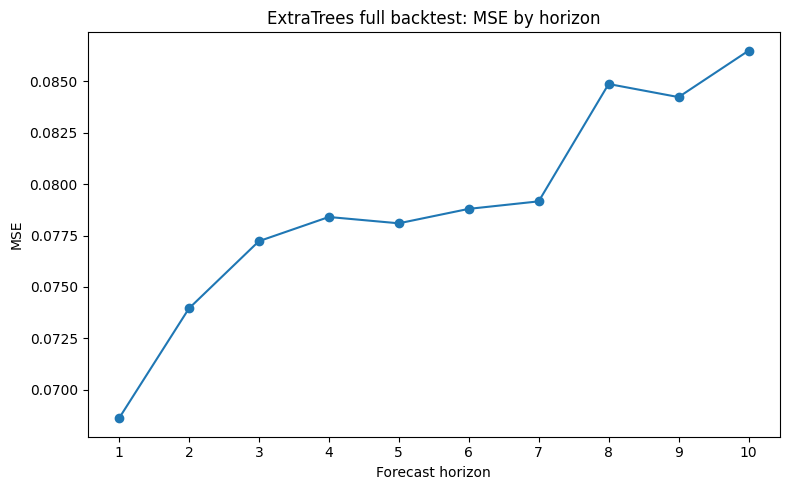

In [223]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    et_full_horizon_metrics["horizon"],
    et_full_horizon_metrics["MSE"],
    marker="o"
)

plt.xlabel("Forecast horizon")
plt.ylabel("MSE")
plt.title("ExtraTrees full backtest: MSE by horizon")
plt.xticks(range(1, HORIZON + 1))
plt.tight_layout()
plt.show()

In [225]:
# ============================================================================
# FULL BASELINE BACKTEST
# ============================================================================

baseline_rows_full = []
baseline_results_full = {}

for baseline_name in BASELINE_MODELS:
    
    print(f"Running baseline: {baseline_name}")
    
    pred_b, actual_b = run_baseline_backtest(
        baseline_name=baseline_name,
        feature_df=feature_df,
        target_col=TARGET,
        train_window=FULL_CONFIG["train_window"],
        horizon=FULL_CONFIG["horizon"],
        backtest_step=FULL_CONFIG["backtest_step"],
        fast_horizons=FULL_CONFIG["fast_horizons"],
    )
    
    m = compute_metrics(actual_b, pred_b)
    m["model"] = baseline_name
    m["feature_set"] = "baseline"
    m["n_features"] = 0
    
    baseline_rows_full.append(m)
    
    baseline_results_full[baseline_name] = {
        "pred_matrix": pred_b,
        "actual_matrix": actual_b,
        "metrics": m
    }

baseline_full_summary = pd.DataFrame(baseline_rows_full)

baseline_full_summary = baseline_full_summary[
    ["model", "feature_set", "n_features", "MSE", "RMSE", "MAE", "R2", "Pearson", "Spearman", "N"]
].sort_values("MSE")

baseline_full_summary

Running baseline: naive_last_value
Running baseline: naive_last_week
Running baseline: rolling_mean_7
Running baseline: rolling_mean_28
Running baseline: ema_7
Running baseline: ema_14


,model,feature_set,n_features,MSE,RMSE,MAE,R2,Pearson,Spearman,N
5,ema_14,baseline,0,0.088173,0.296939,0.223003,0.304998,0.568368,0.561137,8310
3,rolling_mean_28,baseline,0,0.088917,0.298190,0.224097,0.299131,0.558566,0.558653,8310
4,ema_7,baseline,0,0.094316,0.307109,0.231445,0.256575,0.547888,0.534921,8310
2,rolling_mean_7,baseline,0,0.095253,0.308631,0.232886,0.249191,0.544203,0.527977,8310
0,naive_last_value,baseline,0,0.137769,0.371173,0.276261,-0.085934,0.457496,0.456416,8310
1,naive_last_week,baseline,0,0.157577,0.396960,0.297185,-0.242064,0.378998,0.383669,8310


In [229]:
# ============================================================================
# HORIZON COMPARISON: EXTRA TREES VS BASELINES
# ============================================================================

horizon_rows_full = []

horizon_rows_full.append(
    et_full_horizon_metrics.assign(
        feature_set="target_history_calendar_holiday",
        n_features=len(best_feature_cols)
    )
)

for baseline_name, result in baseline_results_full.items():
    tmp = compute_metrics_by_horizon(
        actual_matrix=result["actual_matrix"],
        pred_matrix=result["pred_matrix"],
        model_name=baseline_name
    )
    
    tmp["feature_set"] = "baseline"
    tmp["n_features"] = 0
    
    horizon_rows_full.append(tmp)

horizon_full_compare = pd.concat(horizon_rows_full, ignore_index=True)

horizon_full_compare = horizon_full_compare[
    ["model", "feature_set", "n_features", "horizon", "MSE", "RMSE", "MAE", "R2", "Pearson", "Spearman", "N"]
].sort_values(["horizon", "MSE"])

horizon_full_compare

,model,feature_set,n_features,horizon,MSE,RMSE,MAE,R2,Pearson,Spearman,N
0,extra_trees_full,target_history_calendar_holiday,33,1,0.068607,0.261930,0.195604,0.460161,0.678647,0.683758,831
50,ema_7,baseline,0,1,0.072271,0.268832,0.203070,0.431335,0.663286,0.662522,831
60,ema_14,baseline,0,1,0.074068,0.272154,0.204686,0.417193,0.648156,0.645441,831
10,naive_last_value,baseline,0,1,0.074150,0.272305,0.202455,0.416548,0.708269,0.720680,831
30,rolling_mean_7,baseline,0,1,0.077156,0.277769,0.210689,0.392896,0.638532,0.625193,831
...,...,...,...,...,...,...,...,...,...,...,...
69,ema_14,baseline,0,10,0.099787,0.315891,0.236525,0.213005,0.502982,0.507390,831
39,rolling_mean_7,baseline,0,10,0.106091,0.325716,0.243585,0.163288,0.487840,0.494159,831
59,ema_7,baseline,0,10,0.113076,0.336268,0.251686,0.108197,0.449943,0.451897,831
29,naive_last_week,baseline,0,10,0.178547,0.422548,0.325288,-0.408155,0.296160,0.277878,831


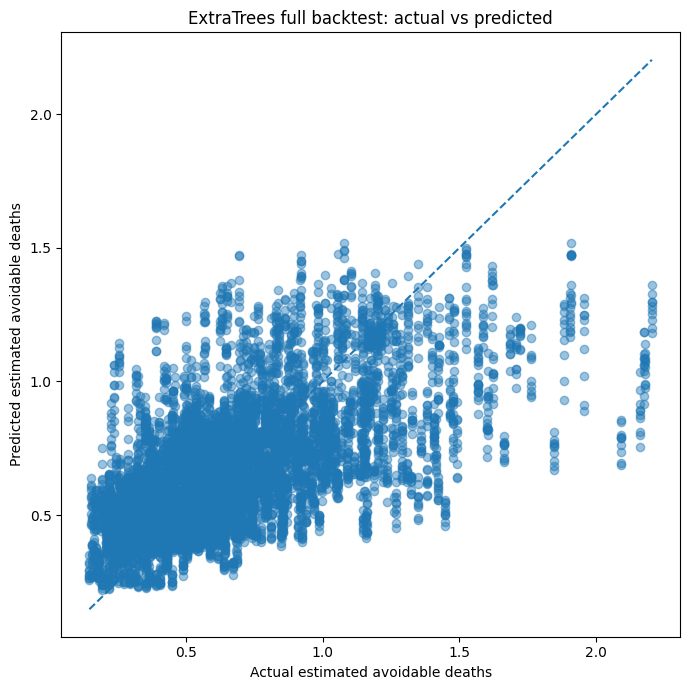

In [230]:
# ============================================================================
# ACTUAL VS PREDICTION PLOT
# ============================================================================

actual_flat = actual_matrix_et_full.flatten()
pred_flat = pred_matrix_et_full.flatten()

valid = np.isfinite(actual_flat) & np.isfinite(pred_flat)

actual_valid = actual_flat[valid]
pred_valid = pred_flat[valid]

plt.figure(figsize=(7, 7))

plt.scatter(actual_valid, pred_valid, alpha=0.45)

min_val = min(actual_valid.min(), pred_valid.min())
max_val = max(actual_valid.max(), pred_valid.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual estimated avoidable deaths")
plt.ylabel("Predicted estimated avoidable deaths")
plt.title("ExtraTrees full backtest: actual vs predicted")

plt.tight_layout()
plt.show()

In [213]:
# ============================================================================
# 9. OUTPUT ACTUAL MATRIX
# ============================================================================

actual_out = pd.DataFrame(
    actual_matrix,
    columns=[f"day_{i}" for i in range(1, HORIZON + 1)]
)

actual_out.insert(0, "forecast_id", np.arange(1, n_forecasts + 1))
actual_out = actual_out.merge(forecast_info_df[["forecast_id", "origin_date"]], on="forecast_id", how="left")

actual_out.to_csv("actual_matrix.csv", index=False)

actual_out.head()

,forecast_id,day_1,day_2,day_3,day_4,day_5,day_6,day_7,day_8,day_9,day_10,origin_date
0,1,0.772160,0.610083,0.289794,0.171848,0.262524,0.402627,0.264732,0.441769,0.352949,0.243103,2023-06-13
1,2,0.610083,0.289794,0.171848,0.262524,0.402627,0.264732,0.441769,0.352949,0.243103,0.209936,2023-06-14
2,3,0.289794,0.171848,0.262524,0.402627,0.264732,0.441769,0.352949,0.243103,0.209936,0.218245,2023-06-15
3,4,0.171848,0.262524,0.402627,0.264732,0.441769,0.352949,0.243103,0.209936,0.218245,0.309583,2023-06-16
4,5,0.262524,0.402627,0.264732,0.441769,0.352949,0.243103,0.209936,0.218245,0.309583,0.499287,2023-06-17


In [214]:
# ============================================================================
# 10. MSE SUMMARY
# ============================================================================

def mse(a, p):
    a = np.asarray(a, dtype=float)
    p = np.asarray(p, dtype=float)
    valid = np.isfinite(a) & np.isfinite(p)
    if valid.sum() == 0:
        return np.nan
    return np.mean((a[valid] - p[valid]) ** 2)


mse_rows = []

for i in range(n_forecasts):
    a = actual_matrix[i, :]
    p = pred_matrix[i, :]
    
    mse_rows.append({
        "forecast_id": i + 1,
        "origin_date": forecast_info_df.loc[i, "origin_date"],
        "mse_1_5": mse(a[:5], p[:5]),
        "mse_6_10": mse(a[5:10], p[5:10]),
        "mse_1_10": mse(a[:10], p[:10])
    })

mse_df = pd.DataFrame(mse_rows)

mse_df.to_csv("mse_summary.csv", index=False)

mse_df.head(100)

,forecast_id,origin_date,mse_1_5,mse_6_10,mse_1_10
0,1,2023-06-13,0.099101,0.082013,0.090557
1,2,2023-06-14,0.092374,0.155792,0.124083
2,3,2023-06-15,0.086506,0.099974,0.093240
3,4,2023-06-16,0.047964,0.021448,0.034706
4,5,2023-06-17,0.027895,0.028538,0.028217
...,...,...,...,...,...
95,96,2023-09-16,0.032028,0.097538,0.064783
96,97,2023-09-17,0.008759,0.078221,0.043490
97,98,2023-09-18,0.002574,0.052627,0.027601
98,99,2023-09-19,0.056909,0.074892,0.065901


In [215]:
# ============================================================================
# 11. OVERALL PERFORMANCE
# ============================================================================

overall = pd.DataFrame({
    "metric": ["mse_1_5", "mse_6_10", "mse_1_10"],
    "mean_mse": [
        mse_df["mse_1_5"].mean(skipna=True),
        mse_df["mse_6_10"].mean(skipna=True),
        mse_df["mse_1_10"].mean(skipna=True)
    ]
})

overall.to_csv("overall_mse.csv", index=False)

overall

,metric,mean_mse
0,mse_1_5,0.118768
1,mse_6_10,0.136128
2,mse_1_10,0.127448


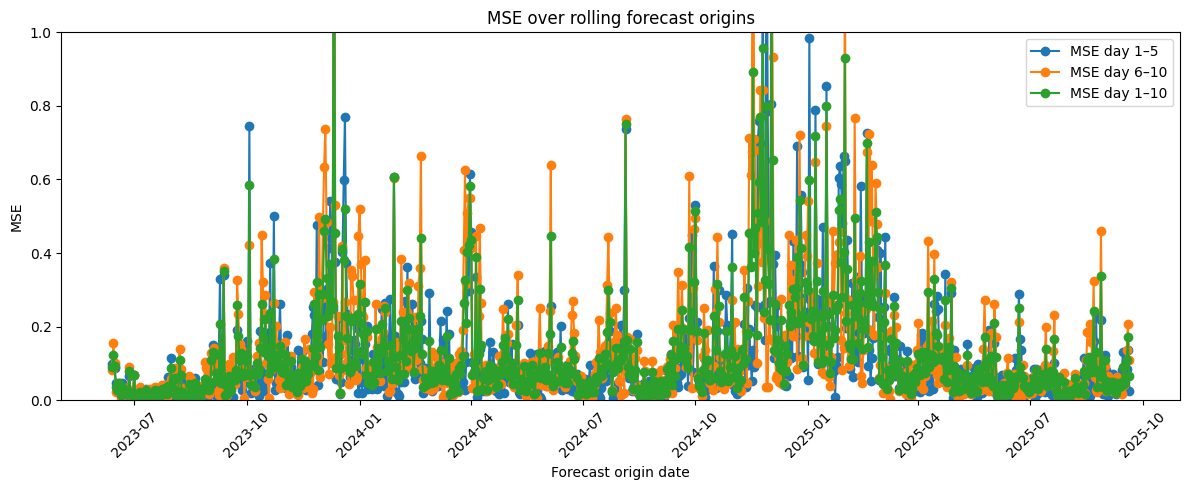

In [124]:
# ============================================================================
# 12. PLOT MSE BY FORECAST ORIGIN
# ============================================================================

import matplotlib.pyplot as plt

# Make sure origin_date is datetime
mse_df["origin_date"] = pd.to_datetime(mse_df["origin_date"])

plt.figure(figsize=(12, 5))

plt.plot(mse_df["origin_date"], mse_df["mse_1_5"], marker="o", label="MSE day 1–5")
plt.plot(mse_df["origin_date"], mse_df["mse_6_10"], marker="o", label="MSE day 6–10")
plt.plot(mse_df["origin_date"], mse_df["mse_1_10"], marker="o", label="MSE day 1–10")

plt.xlabel("Forecast origin date")
plt.ylabel("MSE")
plt.title("MSE over rolling forecast origins")
plt.legend()
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.tight_layout()

plt.savefig("mse_by_forecast_origin.png", dpi=300)
plt.show()

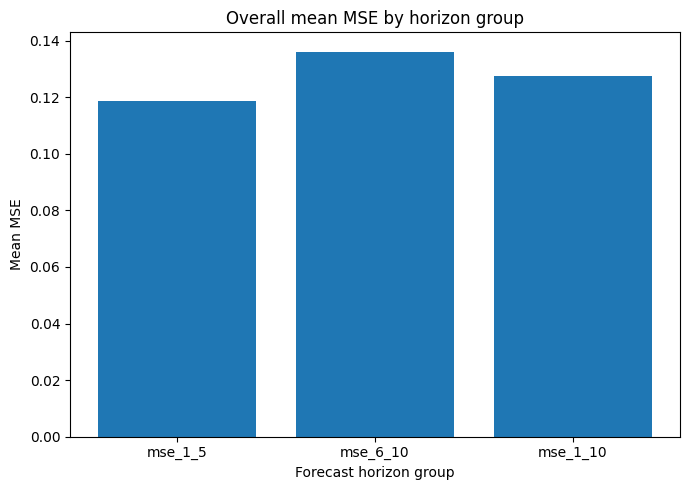

In [125]:
# ============================================================================
# 13. PLOT OVERALL MEAN MSE
# ============================================================================

plt.figure(figsize=(7, 5))

plt.bar(overall["metric"], overall["mean_mse"])

plt.xlabel("Forecast horizon group")
plt.ylabel("Mean MSE")
plt.title("Overall mean MSE by horizon group")
plt.tight_layout()

plt.savefig("overall_mean_mse.png", dpi=300)
plt.show()

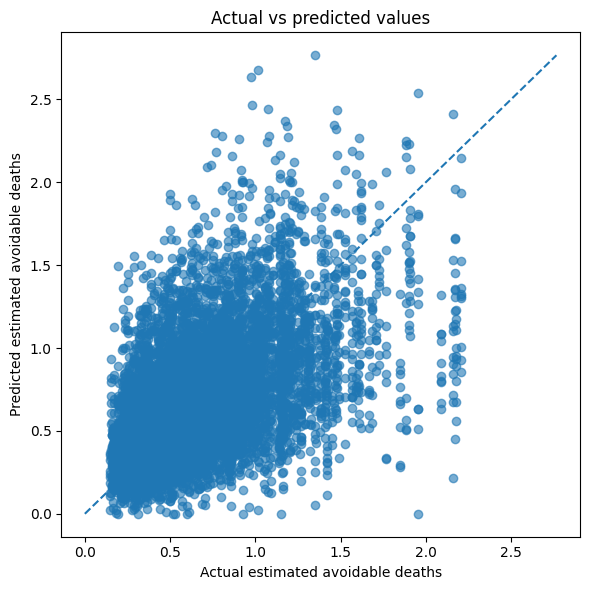

In [128]:
# ============================================================================
# 14. ACTUAL VS PREDICTION SCATTER PLOT
# ============================================================================

actual_flat = actual_matrix.flatten()
pred_flat = pred_matrix.flatten()

valid = np.isfinite(actual_flat) & np.isfinite(pred_flat)

actual_valid = actual_flat[valid]
pred_valid = pred_flat[valid]

plt.figure(figsize=(6, 6))

plt.scatter(actual_valid, pred_valid, alpha=0.6)

# 45-degree reference line
min_val = min(actual_valid.min(), pred_valid.min())
max_val = max(actual_valid.max(), pred_valid.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual estimated avoidable deaths")
plt.ylabel("Predicted estimated avoidable deaths")
plt.title("Actual vs predicted values")
# plt.ylim(0, 2.2)
# plt.xlim(0, 2.2)
plt.tight_layout()

plt.savefig("actual_vs_prediction_scatter.png", dpi=300)
plt.show()

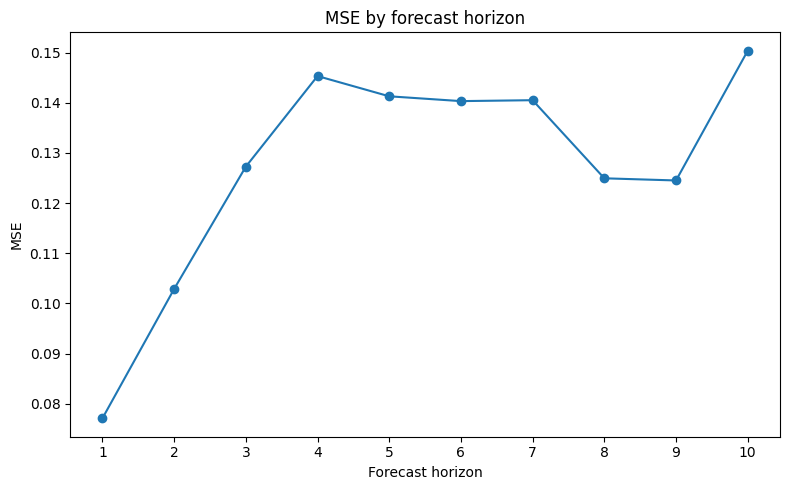

,horizon,mse
0,1,0.077106
1,2,0.102880
2,3,0.127260
3,4,0.145314
4,5,0.141281
5,6,0.140322
6,7,0.140505
7,8,0.124939
8,9,0.124509
9,10,0.150365


In [130]:
# ============================================================================
# 17. MSE BY INDIVIDUAL HORIZON
# ============================================================================

horizon_mse_rows = []

for h in range(1, HORIZON + 1):
    a = actual_matrix[:, h - 1]
    p = pred_matrix[:, h - 1]
    
    horizon_mse_rows.append({
        "horizon": h,
        "mse": mse(a, p)
    })

horizon_mse_df = pd.DataFrame(horizon_mse_rows)

plt.figure(figsize=(8, 5))

plt.plot(horizon_mse_df["horizon"], horizon_mse_df["mse"], marker="o")

plt.xlabel("Forecast horizon")
plt.ylabel("MSE")
plt.title("MSE by forecast horizon")
plt.xticks(range(1, HORIZON + 1))
plt.tight_layout()

plt.savefig("mse_by_horizon.png", dpi=300)
plt.show()

horizon_mse_df

In [131]:
# Flatten prediction / actual into long format
debug_rows = []

for i in range(n_forecasts):
    origin_date = forecast_info_df.loc[i, "origin_date"]
    
    for h in range(1, HORIZON + 1):
        debug_rows.append({
            "forecast_id": i + 1,
            "origin_date": pd.to_datetime(origin_date),
            "horizon": h,
            "target_date": pd.to_datetime(origin_date) + pd.Timedelta(days=h),
            "actual": actual_matrix[i, h - 1],
            "prediction": pred_matrix[i, h - 1],
            "error": actual_matrix[i, h - 1] - pred_matrix[i, h - 1],
            "squared_error": (actual_matrix[i, h - 1] - pred_matrix[i, h - 1]) ** 2
        })

debug_df = pd.DataFrame(debug_rows)

debug_df.sort_values("prediction", ascending=False).head(20)

,forecast_id,origin_date,horizon,target_date,actual,prediction,error,squared_error
5745,575,2025-01-07,6,2025-01-13,1.348706,2.765738,-1.417032,2.007979
1811,182,2023-12-11,2,2023-12-13,1.016691,2.675149,-1.658458,2.750483
1816,182,2023-12-11,7,2023-12-18,0.974911,2.636502,-1.661591,2.760886
5316,532,2024-11-25,7,2024-12-02,1.954645,2.538849,-0.584204,0.341295
5744,575,2025-01-07,5,2025-01-12,0.982362,2.466625,-1.484263,2.203038
5315,532,2024-11-25,6,2024-12-01,1.071591,2.443804,-1.372213,1.882967
5311,532,2024-11-25,2,2024-11-27,1.477930,2.433790,-0.955859,0.913667
5300,531,2024-11-24,1,2024-11-25,2.159445,2.411483,-0.252038,0.063523
5988,599,2025-01-31,9,2025-02-09,1.175975,2.366325,-1.190350,1.416933
5835,584,2025-01-16,6,2025-01-22,1.463576,2.347538,-0.883962,0.781389


In [132]:
debug_no_extreme = debug_df[debug_df["prediction"] < 100]

print("Original MSE:")
print(np.mean(debug_df["squared_error"]))

print("MSE without prediction > 100:")
print(np.mean(debug_no_extreme["squared_error"]))

Original MSE:
0.12744807853419562
MSE without prediction > 100:
0.12744807853419562


In [133]:
# ============================================================================
# DEBUG ONE BAD FORECAST
# ============================================================================

forecast_id_bad = 455
h_bad = 9

origin_pos_bad = TRAIN_WINDOW - 1 + (forecast_id_bad - 1)
origin_date_bad = feature_df.loc[origin_pos_bad, "midday_day"]

max_train_origin_bad = origin_pos_bad - h_bad

train_origin_positions_bad = np.arange(0, max_train_origin_bad + 1)

if len(train_origin_positions_bad) > TRAIN_WINDOW:
    train_origin_positions_bad = train_origin_positions_bad[-TRAIN_WINDOW:]

target_positions_bad = train_origin_positions_bad + h_bad

X_train_bad = feature_df.loc[train_origin_positions_bad, feature_cols]
y_train_bad = feature_df.loc[target_positions_bad, TARGET].values
X_origin_bad = feature_df.loc[[origin_pos_bad], feature_cols]

valid = np.isfinite(y_train_bad)
X_train_bad = X_train_bad.loc[valid]
y_train_bad = y_train_bad[valid]

print("Origin date:", origin_date_bad)
print("Horizon:", h_bad)
print("Target date:", feature_df.loc[origin_pos_bad + h_bad, "midday_day"])
print("Actual:", feature_df.loc[origin_pos_bad + h_bad, TARGET])
print("y_train summary:")
print(pd.Series(y_train_bad).describe())

model_bad = build_model(train_size=len(y_train_bad))
model_bad.fit(X_train_bad, y_train_bad)

pred_bad = model_bad.predict(X_origin_bad)[0]
print("Prediction:", pred_bad)
# If model is TransformedTargetRegressor
if hasattr(model_bad, "regressor_"):
    pipe_bad = model_bad.regressor_
    log_pred_bad = pipe_bad.predict(X_origin_bad)[0]
    
    print("Prediction on transformed y scale:", log_pred_bad)
    print("Back transformed:", np.expm1(log_pred_bad))
else:
    pipe_bad = model_bad

Origin date: 2024-09-09 00:00:00
Horizon: 9
Target date: 2024-09-18 00:00:00
Actual: 0.813428857496526
y_train summary:
count    90.000000
mean      0.470772
std       0.210760
min       0.152920
25%       0.312651
50%       0.428994
75%       0.578750
max       1.267397
dtype: float64
Prediction: 0.5665906033249748


In [136]:
debug_clean = debug_df[
    (np.isfinite(debug_df["actual"])) &
    (np.isfinite(debug_df["prediction"])) &
    (debug_df["prediction"] < 100)
].copy()
# ============================================================================
# METRICS AFTER REMOVING OUTLIER
# ============================================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr
import numpy as np

a = debug_clean["actual"].values
p = debug_clean["prediction"].values

rmse = np.sqrt(mean_squared_error(a, p))
mae = mean_absolute_error(a, p)
mse_value = mean_squared_error(a, p)
r2 = r2_score(a, p)
pearson_corr = pearsonr(a, p)[0]
spearman_corr = spearmanr(a, p)[0]

metrics_clean = pd.DataFrame({
    "metric": ["MSE", "RMSE", "MAE", "R2", "Pearson", "Spearman"],
    "value": [mse_value, rmse, mae, r2, pearson_corr, spearman_corr]
})

metrics_clean

,metric,value
0,MSE,0.127448
1,RMSE,0.356999
2,MAE,0.265007
3,R2,-0.004579
4,Pearson,0.506515
5,Spearman,0.507642


In [139]:
# ============================================================================
# NAIVE BASELINE: last observed y at forecast origin
# ============================================================================

debug_clean["naive_prediction"] = debug_clean["origin_date"].map(
    dict(zip(
        pd.to_datetime(feature_df["midday_day"]),
        feature_df[TARGET]
    ))
)

baseline_rows = []

for h in range(1, HORIZON + 1):
    d = debug_clean[debug_clean["horizon"] == h].copy()
    
    model_mse = np.mean((d["actual"] - d["prediction"]) ** 2)
    naive_mse = np.mean((d["actual"] - d["naive_prediction"]) ** 2)
    
    model_mae = np.mean(np.abs(d["actual"] - d["prediction"]))
    naive_mae = np.mean(np.abs(d["actual"] - d["naive_prediction"]))
    
    baseline_rows.append({
        "horizon": h,
        "model_mse": model_mse,
        "naive_mse": naive_mse,
        "model_mae": model_mae,
        "naive_mae": naive_mae,
        "mse_improvement": (naive_mse - model_mse) / naive_mse,
        "mae_improvement": (naive_mae - model_mae) / naive_mae
    })

baseline_compare = pd.DataFrame(baseline_rows)
baseline_compare

,horizon,model_mse,naive_mse,model_mae,naive_mae,mse_improvement,mae_improvement
0,1,0.077106,0.074150,0.206754,0.202455,-0.039860,-0.021233
1,2,0.102880,0.124589,0.239701,0.260969,0.174244,0.081494
2,3,0.127260,0.156461,0.264304,0.296682,0.186633,0.109135
3,4,0.145314,0.162536,0.283106,0.305522,0.105957,0.073369
4,5,0.141281,0.150670,0.278582,0.290087,0.062315,0.039663
5,6,0.140322,0.131527,0.279454,0.271694,-0.066861,-0.028562
6,7,0.140505,0.112868,0.282911,0.249361,-0.244864,-0.134543
7,8,0.124939,0.127176,0.261009,0.264937,0.017589,0.014826
8,9,0.124509,0.157282,0.265468,0.298792,0.208372,0.111527
9,10,0.150365,0.180435,0.288781,0.322109,0.166648,0.103466


In [142]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd

actual_flat = actual_matrix.flatten()
pred_flat = pred_matrix.flatten()

valid = np.isfinite(actual_flat) & np.isfinite(pred_flat)

a = actual_flat[valid]
p = pred_flat[valid]

metrics = pd.DataFrame({
    "metric": ["MSE", "RMSE", "MAE", "R2", "Pearson", "Spearman"],
    "value": [
        mean_squared_error(a, p),
        np.sqrt(mean_squared_error(a, p)),
        mean_absolute_error(a, p),
        r2_score(a, p),
        pearsonr(a, p)[0],
        spearmanr(a, p)[0]
    ]
})

metrics

,metric,value
0,MSE,0.127448
1,RMSE,0.356999
2,MAE,0.265007
3,R2,-0.004579
4,Pearson,0.506515
5,Spearman,0.507642
